# ☕ Analyse des Ventes d'un Café – Dashboard Interactif
## DS2 – Étude de cas appliquée en Data Science
**Promotion : 1LIG | Jeu de données : dirty_cafe_sales.csv (10 000 transactions)**

---
## 1. Importation des bibliothèques

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

print('Bibliotheques importees avec succes')

Bibliotheques importees avec succes


---
## 2. Chargement du jeu de données

In [32]:
df = pd.read_csv('dirty_cafe_sales.csv')

print(f'Donnees chargees : {df.shape[0]} lignes x {df.shape[1]} colonnes')
print('\nColonnes disponibles :')
print(df.columns.tolist())

Donnees chargees : 10000 lignes x 8 colonnes

Colonnes disponibles :
['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date']


---
## 3. Exploration initiale

In [33]:
print('=== PREMIERES LIGNES ===')
display(df.head(10))

=== PREMIERES LIGNES ===


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


In [34]:
print('=== DERNIERES LIGNES ===')
display(df.tail(5))

=== DERNIERES LIGNES ===


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02
9999,TXN_6170729,Sandwich,3,4.0,12.0,Cash,In-store,2023-11-07


In [35]:
print(f'Dimensions : {df.shape[0]} lignes x {df.shape[1]} colonnes')
print('\nTypes des variables :')
print(df.dtypes)
print('\n=== INFORMATIONS GENERALES ===')
df.info()

Dimensions : 10000 lignes x 8 colonnes

Types des variables :
Transaction ID      str
Item                str
Quantity            str
Price Per Unit      str
Total Spent         str
Payment Method      str
Location            str
Transaction Date    str
dtype: object

=== INFORMATIONS GENERALES ===
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 1.1 MB


In [36]:
print('=== STATISTIQUES DESCRIPTIVES (avant nettoyage) ===')
display(df.describe(include='all'))

=== STATISTIQUES DESCRIPTIVES (avant nettoyage) ===


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


---
## 4. Detection et traitement des problemes de qualite

In [37]:
# --- Doublons ---
nb_doublons = df.duplicated().sum()
print(f'Nombre de doublons : {nb_doublons}')

if nb_doublons > 0:
    df.drop_duplicates(inplace=True)
    print(f'Doublons supprimes. Nouvelles dimensions : {df.shape}')
else:
    print('Aucun doublon detecte')

Nombre de doublons : 0
Aucun doublon detecte


In [38]:
# --- Valeurs manquantes (NaN natifs) ---
print('Valeurs manquantes par colonne :')
print(df.isnull().sum())

Valeurs manquantes par colonne :
Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64


In [39]:
# --- Valeurs corrompues : ERROR et UNKNOWN ---
for col in df.columns:
    n_error   = (df[col] == 'ERROR').sum()
    n_unknown = (df[col] == 'UNKNOWN').sum()
    if n_error > 0 or n_unknown > 0:
        print(f'{col:20s} --> ERROR: {n_error:4d} | UNKNOWN: {n_unknown:4d}')

Item                 --> ERROR:  292 | UNKNOWN:  344
Quantity             --> ERROR:  170 | UNKNOWN:  171
Price Per Unit       --> ERROR:  190 | UNKNOWN:  164
Total Spent          --> ERROR:  164 | UNKNOWN:  165
Payment Method       --> ERROR:  306 | UNKNOWN:  293
Location             --> ERROR:  358 | UNKNOWN:  338
Transaction Date     --> ERROR:  142 | UNKNOWN:  159


In [40]:
# Remplacer ERROR et UNKNOWN par NaN
df.replace(['ERROR', 'UNKNOWN'], np.nan, inplace=True)

print('Valeurs ERROR et UNKNOWN remplacees par NaN')
print('\nNouveau compte de valeurs manquantes :')
print(df.isnull().sum())

Valeurs ERROR et UNKNOWN remplacees par NaN

Nouveau compte de valeurs manquantes :
Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64


In [41]:
# --- Conversion des types ---
df['Quantity']         = pd.to_numeric(df['Quantity'],         errors='coerce')
df['Price Per Unit']   = pd.to_numeric(df['Price Per Unit'],   errors='coerce')
df['Total Spent']      = pd.to_numeric(df['Total Spent'],      errors='coerce')
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

print('Types convertis')
print(df.dtypes)

Types convertis
Transaction ID                 str
Item                           str
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method                 str
Location                       str
Transaction Date    datetime64[us]
dtype: object


In [42]:
# --- Traitement des valeurs manquantes ---

# Colonnes numeriques : remplacer par la mediane
for col in ['Quantity', 'Price Per Unit', 'Total Spent']:
    mediane = df[col].median()
    df[col].fillna(mediane, inplace=True)
    print(f'  {col}: NaN remplace par mediane ({mediane})')

# Colonnes categorielles : remplacer par la valeur la plus frequente (mode)
for col in ['Item', 'Payment Method', 'Location']:
    mode_val = df[col].mode().iloc[0]
    df[col].fillna(mode_val, inplace=True)
    print(f'  {col}: NaN remplace par mode ({mode_val})')

# Dates manquantes : supprimer ces lignes
nb_dates_null = df['Transaction Date'].isnull().sum()
df.dropna(subset=['Transaction Date'], inplace=True)
print(f'  Transaction Date: {nb_dates_null} lignes supprimees (date manquante)')

df.reset_index(drop=True, inplace=True)
print(f'\nNettoyage termine. Dimensions finales : {df.shape}')

  Quantity: NaN remplace par mediane (3.0)
  Price Per Unit: NaN remplace par mediane (3.0)
  Total Spent: NaN remplace par mediane (8.0)
  Item: NaN remplace par mode (Juice)
  Payment Method: NaN remplace par mode (Digital Wallet)
  Location: NaN remplace par mode (Takeaway)
  Transaction Date: 460 lignes supprimees (date manquante)

Nettoyage termine. Dimensions finales : (9540, 8)


---
## 5. Enrichissement temporel

In [43]:
# Extraction des composantes de date
df['Annee']        = df['Transaction Date'].dt.year
df['Mois']         = df['Transaction Date'].dt.month
df['Jour']         = df['Transaction Date'].dt.day
df['Jour_Semaine'] = df['Transaction Date'].dt.dayofweek
df['Nom_Jour']     = df['Transaction Date'].dt.day_name()
df['Semaine']      = df['Transaction Date'].dt.isocalendar().week.astype(int)

# Tri par date
df.sort_values(by='Transaction Date', inplace=True)
df.reset_index(drop=True, inplace=True)

print('Composantes temporelles extraites')
display(df[['Transaction Date','Annee','Mois','Jour','Nom_Jour']].head(5))

Composantes temporelles extraites


,Transaction Date,Annee,Mois,Jour,Nom_Jour
0,2023-01-01,2023,1,1,Sunday
1,2023-01-01,2023,1,1,Sunday
2,2023-01-01,2023,1,1,Sunday
3,2023-01-01,2023,1,1,Sunday
4,2023-01-01,2023,1,1,Sunday


In [44]:
# Renommer les colonnes
df.rename(columns={
    'Transaction ID'   : 'ID_Transaction',
    'Item'             : 'Produit',
    'Quantity'         : 'Quantite',
    'Price Per Unit'   : 'Prix_Unitaire',
    'Total Spent'      : 'Total_Depense',
    'Payment Method'   : 'Mode_Paiement',
    'Location'         : 'Lieu',
    'Transaction Date' : 'Date'
}, inplace=True)

print('Colonnes renommees :')
print(df.columns.tolist())

Colonnes renommees :
['ID_Transaction', 'Produit', 'Quantite', 'Prix_Unitaire', 'Total_Depense', 'Mode_Paiement', 'Lieu', 'Date', 'Annee', 'Mois', 'Jour', 'Jour_Semaine', 'Nom_Jour', 'Semaine']


---
## 6. Calcul des KPI

In [45]:
# KPI globaux
ca_total        = df['Total_Depense'].sum()
nb_transactions = len(df)
panier_moyen    = df['Total_Depense'].mean()
produit_top     = df['Produit'].value_counts().idxmax()
paiement_top    = df['Mode_Paiement'].value_counts().idxmax()
lieu_top        = df['Lieu'].value_counts().idxmax()
quantite_moy    = df['Quantite'].mean()

print('=' * 55)
print('        INDICATEURS CLES DE PERFORMANCE')
print('=' * 55)
print(f'  Chiffre affaires total  : {ca_total:>12,.2f} euro')
print(f'  Nombre de transactions  : {nb_transactions:>12,}')
print(f'  Panier moyen            : {panier_moyen:>12.2f} euro')
print(f'  Produit le + vendu      : {produit_top:>12}')
print(f'  Mode de paiement top    : {paiement_top:>12}')
print(f'  Lieu de vente top       : {lieu_top:>12}')
print(f'  Quantite moyenne/cmd    : {quantite_moy:>12.2f}')
print('=' * 55)

        INDICATEURS CLES DE PERFORMANCE
  Chiffre affaires total  :    80,800.50 euro
  Nombre de transactions  :        9,540
  Panier moyen            :         8.91 euro
  Produit le + vendu      :        Juice
  Mode de paiement top    : Digital Wallet
  Lieu de vente top       :     Takeaway
  Quantite moyenne/cmd    :         3.03


In [46]:
# CA par produit (tri decroissant)
print('=== CA PAR PRODUIT (decroissant) ===')
ca_produit = df.groupby('Produit')['Total_Depense'].sum().sort_values(ascending=False).round(2)
display(ca_produit.to_frame('CA (euro)'))

=== CA PAR PRODUIT (decroissant) ===


,CA (euro)
Produit,
Salad,15855.0
Sandwich,12328.0
Smoothie,12040.0
Juice,9540.0
Cake,9393.0
Coffee,6530.0
Tea,4453.5
Cookie,2922.0


In [47]:
# Analyse complete par produit
print('=== ANALYSE PAR PRODUIT ===')
analyse_produit = df.groupby('Produit').agg(
    CA_Total=('Total_Depense','sum'),
    Nb_Ventes=('ID_Transaction','count'),
    Quantite_Totale=('Quantite','sum'),
    Panier_Moyen=('Total_Depense','mean')
).round(2).sort_values('CA_Total', ascending=False)
display(analyse_produit)

=== ANALYSE PAR PRODUIT ===


,CA_Total,Nb_Ventes,Quantite_Totale,Panier_Moyen
Produit,,,,
Salad,15855.0,1099,3161.0,15.13
Sandwich,12328.0,1075,3089.0,12.17
Smoothie,12040.0,1048,3085.0,12.27
Juice,9540.0,1124,3216.0,8.90
Cake,9393.0,1082,3143.0,9.08
Coffee,6530.0,1123,3251.0,6.08
Tea,4453.5,1027,2975.0,4.54
Cookie,2922.0,1035,2946.0,2.98


In [48]:
# CA mensuel
print('=== CA MENSUEL ===')
noms_mois_full = ['Jan','Fev','Mar','Avr','Mai','Jun','Jul','Aou','Sep','Oct','Nov','Dec']
ca_mensuel = df.groupby('Mois')['Total_Depense'].sum().round(2)
ca_mensuel.index = [noms_mois_full[m-1] for m in ca_mensuel.index]
display(ca_mensuel.to_frame('CA (euro)'))

=== CA MENSUEL ===


,CA (euro)
Jan,6845.0
Fev,6304.0
Mar,6822.0
Avr,6730.5
Mai,6674.0
Jun,7071.5
Jul,6574.0
Aou,6904.0
Sep,6501.5
Oct,7040.5


In [49]:
# Analyse par mode de paiement et lieu
print('=== REPARTITION PAR MODE DE PAIEMENT ===')
paiement_stats = df.groupby('Mode_Paiement')['Total_Depense'].agg(['sum','mean','count']).round(2)
paiement_stats.columns = ['CA Total','Panier Moyen','Nb Transactions']
display(paiement_stats)

print('\n=== REPARTITION PAR LIEU ===')
lieu_stats = df.groupby('Lieu')['Total_Depense'].agg(['sum','mean','count']).round(2)
lieu_stats.columns = ['CA Total','Panier Moyen','Nb Transactions']
display(lieu_stats)

=== REPARTITION PAR MODE DE PAIEMENT ===


,CA Total,Panier Moyen,Nb Transactions
Mode_Paiement,,,
Cash,18489.5,9.07,2038
Credit Card,18654.0,9.01,2071
Digital Wallet,18719.5,8.93,2096



=== REPARTITION PAR LIEU ===


,CA Total,Panier Moyen,Nb Transactions
Lieu,,,
In-store,24650.0,9.03,2729
Takeaway,24149.5,8.78,2749


In [50]:
# Filtrage avec conditions multiples
gros_paniers  = df[df['Total_Depense'] > 15]
print(f'Transactions > 15 euro : {len(gros_paniers)} ({len(gros_paniers)/len(df)*100:.1f}%)')

coffee_digital = df[(df['Produit'] == 'Coffee') & (df['Mode_Paiement'] == 'Digital Wallet')]
print(f'Cafe paye en Digital Wallet : {len(coffee_digital)} transactions')

ventes_physiques = df[df['Lieu'].isin(['In-store', 'Takeaway'])]
print(f'Ventes en presentiel        : {len(ventes_physiques)} transactions')

Transactions > 15 euro : 1387 (14.5%)
Cafe paye en Digital Wallet : 258 transactions
Ventes en presentiel        : 5761 transactions


In [51]:
# value_counts : frequences et pourcentages
print('=== FREQUENCE DES PRODUITS ===')
print(df['Produit'].value_counts())
print('\n=== POURCENTAGE ===')
pct = df['Produit'].value_counts(normalize=True).mul(100).round(2)
print(pct.astype(str) + '%')

=== FREQUENCE DES PRODUITS ===
Produit
Juice       1124
Coffee      1123
Salad       1099
Cake        1082
Sandwich    1075
Smoothie    1048
Cookie      1035
Tea         1027
Name: count, dtype: int64

=== POURCENTAGE ===
Produit
Juice       13.05%
Coffee      13.04%
Salad       12.76%
Cake        12.56%
Sandwich    12.48%
Smoothie    12.17%
Cookie      12.02%
Tea         11.92%
Name: proportion, dtype: str


In [52]:
# Analyse temporelle : CA par mois et par jour
ca_par_mois = df.groupby(df['Date'].dt.month)['Total_Depense'].sum()
print('=== CA PAR MOIS (groupby sur date) ===')
print(ca_par_mois.round(2))

ordre_jours = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
ca_par_jour = df.groupby('Nom_Jour')['Total_Depense'].mean().reindex(ordre_jours).round(2)
print('\n=== CA MOYEN PAR JOUR DE SEMAINE ===')
print(ca_par_jour)

=== CA PAR MOIS (groupby sur date) ===
Date
1     6845.0
2     6304.0
3     6822.0
4     6730.5
5     6674.0
6     7071.5
7     6574.0
8     6904.0
9     6501.5
10    7040.5
11    6532.5
12    6801.0
Name: Total_Depense, dtype: float64

=== CA MOYEN PAR JOUR DE SEMAINE ===
Nom_Jour
Monday       8.84
Tuesday      9.18
Wednesday    8.72
Thursday     9.00
Friday       8.89
Saturday     8.86
Sunday       8.92
Name: Total_Depense, dtype: float64


---
## 7. Visualisations

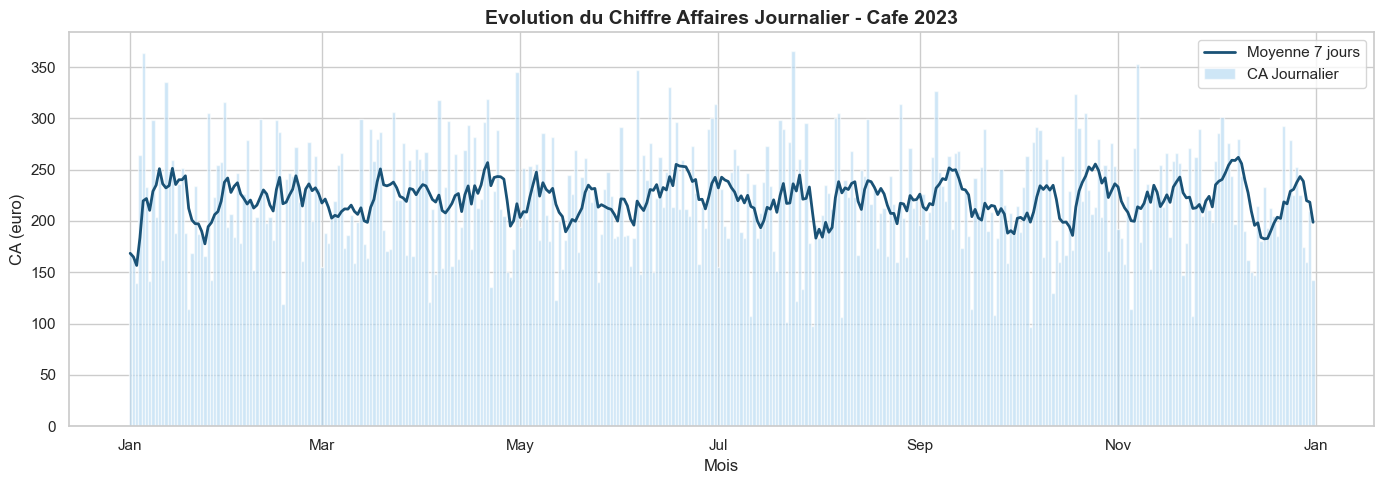

Figure sauvegardee : viz_ca_journalier.png


In [53]:
# ---- VIZ 1 : CA journalier + moyenne mobile ----
ca_daily = df.groupby('Date')['Total_Depense'].sum().reset_index()
ca_daily_roll = ca_daily.set_index('Date')['Total_Depense'].rolling('7D').mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(ca_daily['Date'], ca_daily['Total_Depense'],
       color='#AED6F1', alpha=0.6, width=1, label='CA Journalier')
ax.plot(ca_daily_roll.index, ca_daily_roll.values,
        color='#1A5276', linewidth=2, label='Moyenne 7 jours')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.set_title('Evolution du Chiffre Affaires Journalier - Cafe 2023',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Mois')
ax.set_ylabel('CA (euro)')
ax.legend()
plt.tight_layout()
plt.savefig('viz_ca_journalier.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardee : viz_ca_journalier.png')

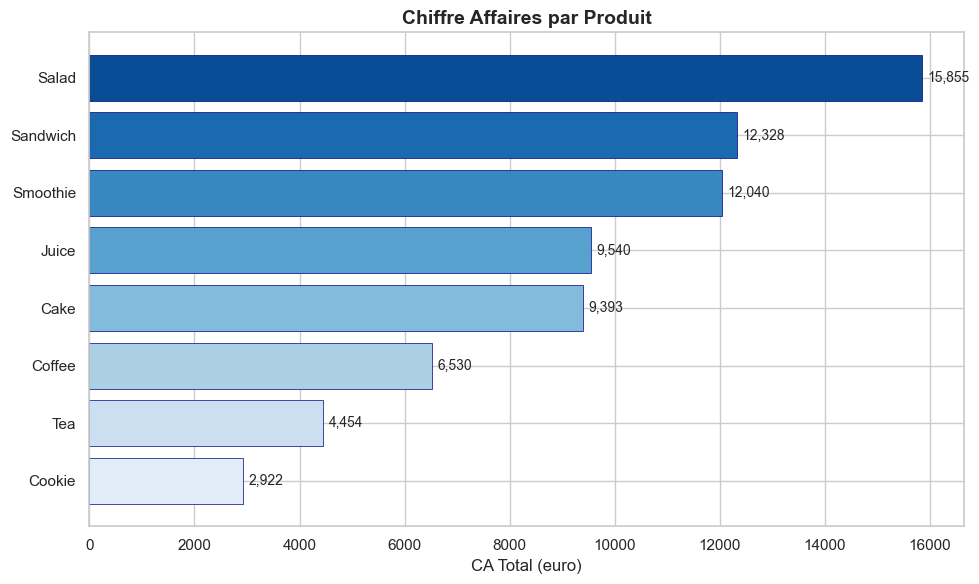

In [54]:
# ---- VIZ 2 : CA par produit (barres horizontales) ----
fig, ax = plt.subplots(figsize=(10, 6))
ca_prod = df.groupby('Produit')['Total_Depense'].sum().sort_values()
colors  = sns.color_palette('Blues', len(ca_prod))
bars    = ax.barh(ca_prod.index, ca_prod.values, color=colors, edgecolor='navy', linewidth=0.5)
for bar, val in zip(bars, ca_prod.values):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=10)
ax.set_title('Chiffre Affaires par Produit', fontsize=14, fontweight='bold')
ax.set_xlabel('CA Total (euro)')
plt.tight_layout()
plt.savefig('viz_ca_produit.png', dpi=150, bbox_inches='tight')
plt.show()

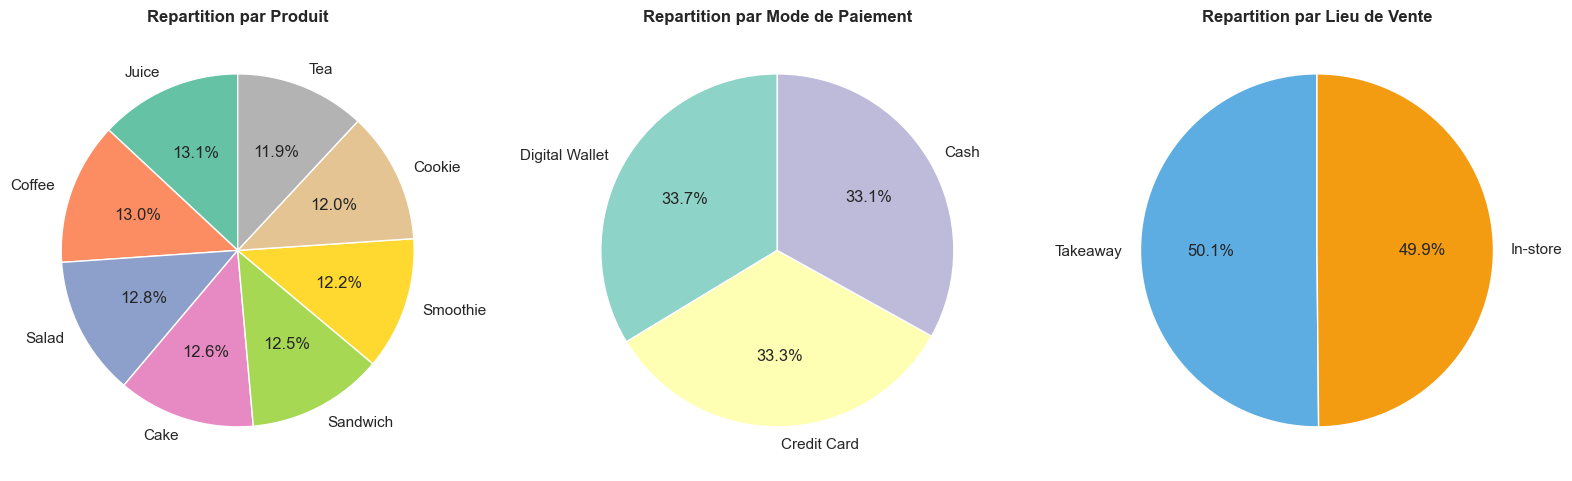

In [55]:
# ---- VIZ 3 : Repartitions (camemberts) ----
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

freq_prod = df['Produit'].value_counts()
axes[0].pie(freq_prod.values, labels=freq_prod.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(freq_prod)), startangle=90)
axes[0].set_title('Repartition par Produit', fontweight='bold')

freq_pay = df['Mode_Paiement'].value_counts()
axes[1].pie(freq_pay.values, labels=freq_pay.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set3', len(freq_pay)), startangle=90)
axes[1].set_title('Repartition par Mode de Paiement', fontweight='bold')

freq_lieu = df['Lieu'].value_counts()
axes[2].pie(freq_lieu.values, labels=freq_lieu.index, autopct='%1.1f%%',
            colors=['#5DADE2','#F39C12'], startangle=90)
axes[2].set_title('Repartition par Lieu de Vente', fontweight='bold')

plt.tight_layout()
plt.savefig('viz_repartitions.png', dpi=150, bbox_inches='tight')
plt.show()

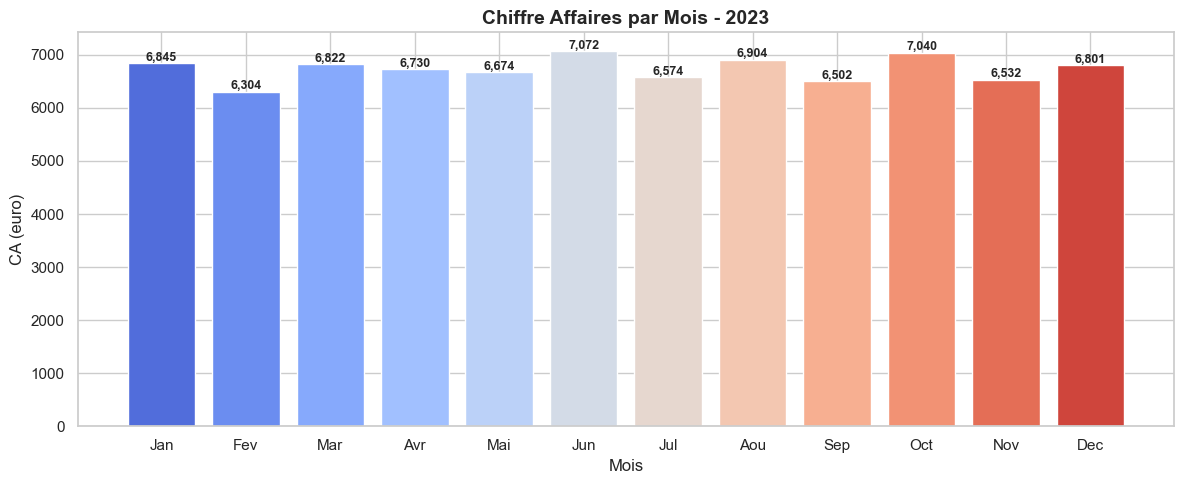

In [56]:
# ---- VIZ 4 : CA mensuel (histogramme) ----
fig, ax = plt.subplots(figsize=(12, 5))
ca_mensuel_vals = df.groupby('Mois')['Total_Depense'].sum()
noms_mois_full  = ['Jan','Fev','Mar','Avr','Mai','Jun','Jul','Aou','Sep','Oct','Nov','Dec']
labels = [noms_mois_full[m-1] for m in ca_mensuel_vals.index]
bars   = ax.bar(labels, ca_mensuel_vals.values,
                color=sns.color_palette('coolwarm', len(ca_mensuel_vals)), edgecolor='white')
for bar, val in zip(bars, ca_mensuel_vals.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,.0f}', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Chiffre Affaires par Mois - 2023', fontsize=14, fontweight='bold')
ax.set_xlabel('Mois')
ax.set_ylabel('CA (euro)')
plt.tight_layout()
plt.savefig('viz_ca_mensuel.png', dpi=150, bbox_inches='tight')
plt.show()

In [57]:
produits = df['Produit'].dropna()
produits = produits.astype(str)
produits = sorted(produits.unique())

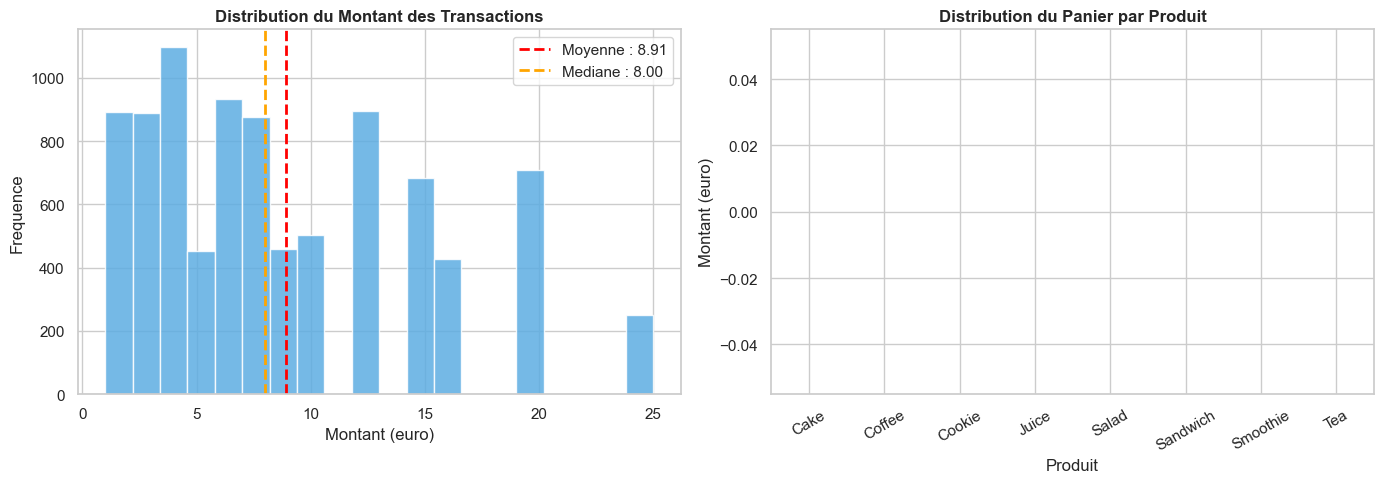

In [58]:
# ---- VIZ 5 : Distribution du panier + boxplot ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Total_Depense'], bins=20, color='#5DADE2', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Total_Depense'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Moyenne : {df["Total_Depense"].mean():.2f}')
axes[0].axvline(df['Total_Depense'].median(), color='orange', linestyle='--', linewidth=2,
                label=f'Mediane : {df["Total_Depense"].median():.2f}')
axes[0].set_title('Distribution du Montant des Transactions', fontweight='bold')
axes[0].set_xlabel('Montant (euro)')
axes[0].set_ylabel('Frequence')
axes[0].legend()

produits = sorted(df['Produit'].dropna().astype(str).unique())
data_box  = [df[df['Produit']==p]['Total_Depense'].values for p in produits]
axes[1].boxplot(data_box, labels=produits, patch_artist=True,
                boxprops=dict(facecolor='#AED6F1', color='steelblue'))
axes[1].set_title('Distribution du Panier par Produit', fontweight='bold')
axes[1].set_xlabel('Produit')
axes[1].set_ylabel('Montant (euro)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('viz_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

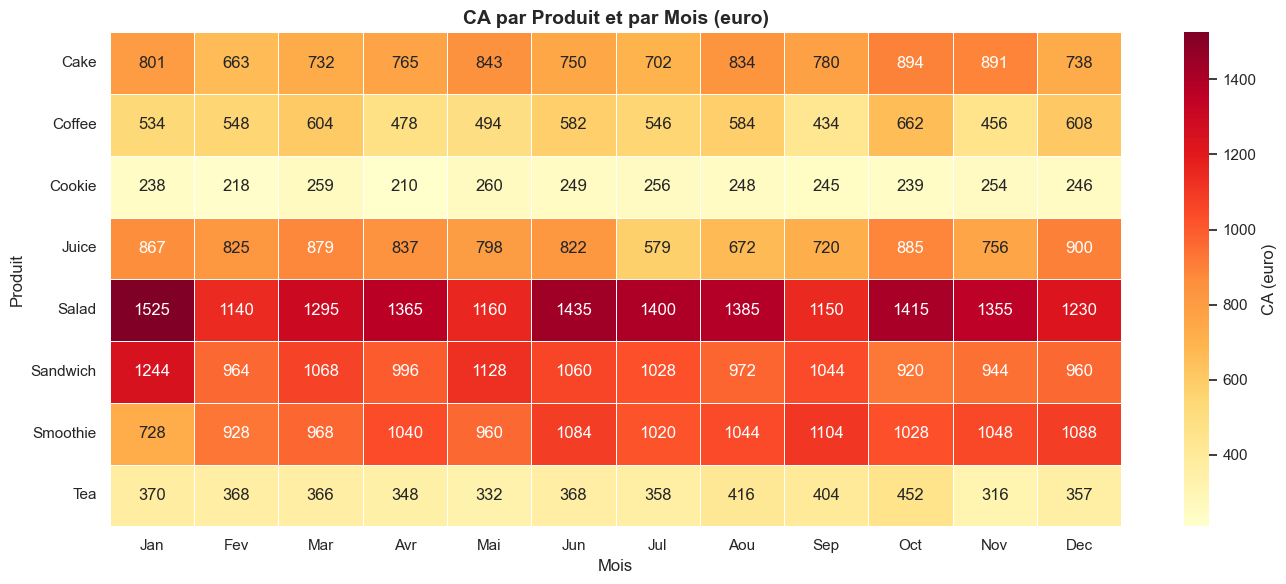

In [59]:
# ---- VIZ 6 : Heatmap Produit x Mois ----
fig, ax = plt.subplots(figsize=(14, 6))
noms_mois_full = ['Jan','Fev','Mar','Avr','Mai','Jun','Jul','Aou','Sep','Oct','Nov','Dec']
pivot = df.pivot_table(values='Total_Depense', index='Produit',
                       columns='Mois', aggfunc='sum', fill_value=0)
pivot.columns = [noms_mois_full[m-1] for m in pivot.columns]
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'CA (euro)'})
ax.set_title('CA par Produit et par Mois (euro)', fontsize=14, fontweight='bold')
ax.set_ylabel('Produit')
ax.set_xlabel('Mois')
plt.tight_layout()
plt.savefig('viz_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

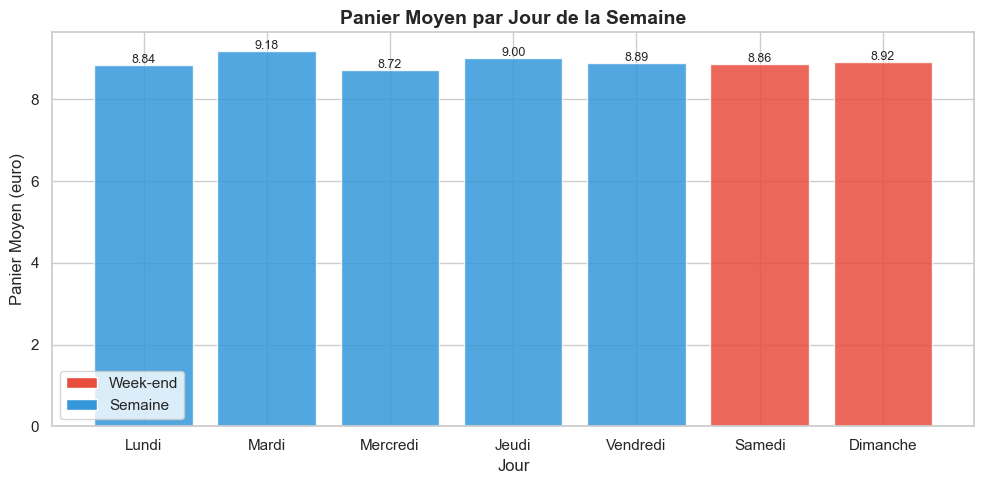

In [60]:
# ---- VIZ 7 : CA par jour de la semaine ----
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(10, 5))
ordre_jours = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
noms_fr     = ['Lundi','Mardi','Mercredi','Jeudi','Vendredi','Samedi','Dimanche']
ca_jour = df.groupby('Nom_Jour')['Total_Depense'].mean().reindex(ordre_jours)
colors  = ['#E74C3C' if j in ['Saturday','Sunday'] else '#3498DB' for j in ordre_jours]
bars    = ax.bar(noms_fr, ca_jour.values, color=colors, edgecolor='white', alpha=0.85)
for bar, val in zip(bars, ca_jour.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', fontsize=9)
ax.set_title('Panier Moyen par Jour de la Semaine', fontsize=14, fontweight='bold')
ax.set_ylabel('Panier Moyen (euro)')
ax.set_xlabel('Jour')
legend_elements = [Patch(facecolor='#E74C3C', label='Week-end'),
                   Patch(facecolor='#3498DB', label='Semaine')]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig('viz_ca_jour_semaine.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Sauvegarde des donnees nettoyees

In [61]:
df.to_csv('cafe_sales_clean.csv', index=False)
print('Donnees nettoyees sauvegardees : cafe_sales_clean.csv')
print(f'Colonnes : {df.columns.tolist()}')
print(f'Lignes   : {len(df)}')

Donnees nettoyees sauvegardees : cafe_sales_clean.csv
Colonnes : ['ID_Transaction', 'Produit', 'Quantite', 'Prix_Unitaire', 'Total_Depense', 'Mode_Paiement', 'Lieu', 'Date', 'Annee', 'Mois', 'Jour', 'Jour_Semaine', 'Nom_Jour', 'Semaine']
Lignes   : 9540


---
## 9. Synthese des resultats

In [62]:
noms_mois_full = ['Jan','Fev','Mar','Avr','Mai','Jun','Jul','Aou','Sep','Oct','Nov','Dec']
mois_top = df.groupby('Mois')['Total_Depense'].sum().idxmax()
jour_top = df.groupby('Nom_Jour')['Total_Depense'].mean().idxmax()

print('=' * 60)
print('              SYNTHESE FINALE')
print('=' * 60)
print(f'  Periode analysee         : Janvier - Decembre 2023')
print(f'  Transactions traitees    : {len(df):,}')
print(f'  Chiffre affaires total   : {df["Total_Depense"].sum():,.2f} euro')
print(f'  Panier moyen             : {df["Total_Depense"].mean():.2f} euro')
print(f'  Produit le + rentable    : {df.groupby("Produit")["Total_Depense"].sum().idxmax()}')
print(f'  Meilleur mois            : {noms_mois_full[mois_top-1]}')
print(f'  Meilleur jour semaine    : {jour_top}')
print(f'  Mode paiement dominant   : {df["Mode_Paiement"].value_counts().idxmax()}')
print(f'  Lieu dominant            : {df["Lieu"].value_counts().idxmax()}')
print('=' * 60)

              SYNTHESE FINALE
  Periode analysee         : Janvier - Decembre 2023
  Transactions traitees    : 9,540
  Chiffre affaires total   : 80,800.50 euro
  Panier moyen             : 8.91 euro
  Produit le + rentable    : Salad
  Meilleur mois            : Jun
  Meilleur jour semaine    : Tuesday
  Mode paiement dominant   : Digital Wallet
  Lieu dominant            : Takeaway
